In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns

from niceplots import plot_surface_vars, plot_level_vars, plot_selection, get_color

In [2]:
plt.style.use("~/nice.mplstyle")

In [67]:
metric = "rmse"
valortest = "testing"
figdict = {}
figdict["NE6"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-{valortest}/obs-metrics/{metric}.convobs.nested-lam.nc", decode_timedelta=True)
figdict["HR"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/hrrr-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)
figdict["G"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/obs-metrics-{valortest}/{metric}.convobs.global.conus.nc", decode_timedelta=True)
figdict["NE 0.25deg"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-{valortest}/obs-metrics/{metric}.convobs.nested-global.conus.nc", decode_timedelta=True)
figdict["G6km"] = xr.load_dataset(f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-hrrr-analysis/trim25/obs-metrics-{valortest}/{metric}.convobs.lam.nc", decode_timedelta=True)

/global/u2/t/timothys/nested-eagle/0.25deg-06km/baselines/niceplots.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0, rect=[0, 0.1, 1, 1])


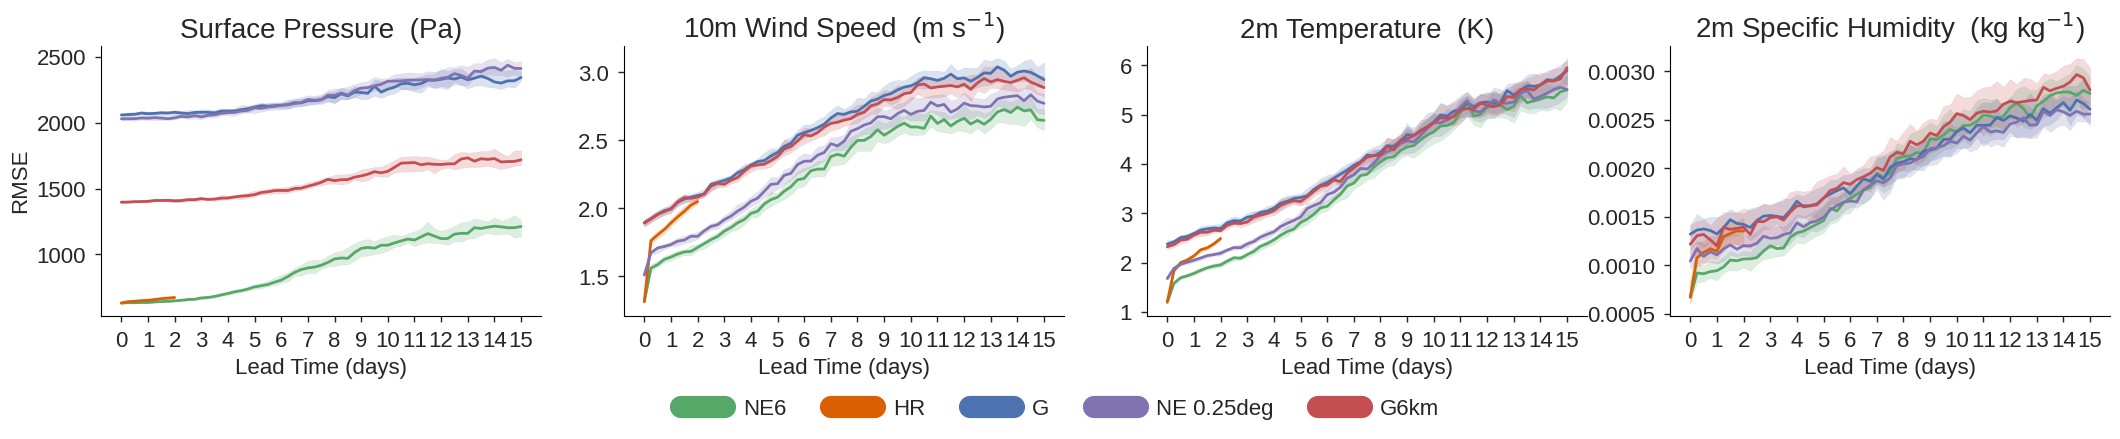

In [68]:
fig, axs = plot_surface_vars(figdict, metric.upper())

In [69]:
for varname in ["2m_temperature", "10m_wind_speed"]:
    NE = figdict["NE6"][varname].sel(fhr=0).mean("t0")
    NEC = figdict["NE 0.25deg"][varname].sel(fhr=0).mean("t0")
    print(NEC - NE)

<xarray.DataArray '2m_temperature' ()> Size: 8B
array(0.46978529)
Coordinates:
    lead_time  timedelta64[ns] 8B 00:00:00
    fhr        int64 8B 0
<xarray.DataArray '10m_wind_speed' ()> Size: 8B
array(0.20804511)
Coordinates:
    lead_time  timedelta64[ns] 8B 00:00:00
    fhr        int64 8B 0


In [10]:
gsix = xr.open_zarr("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-hrrr-analysis/gfs.forecasts.zarr/")
gfs = xr.open_zarr("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/baselines/gfs-forecasts-vs-gfs-analysis/gfs.forecasts.zarr/")

In [11]:
import cartopy.crs as ccrs

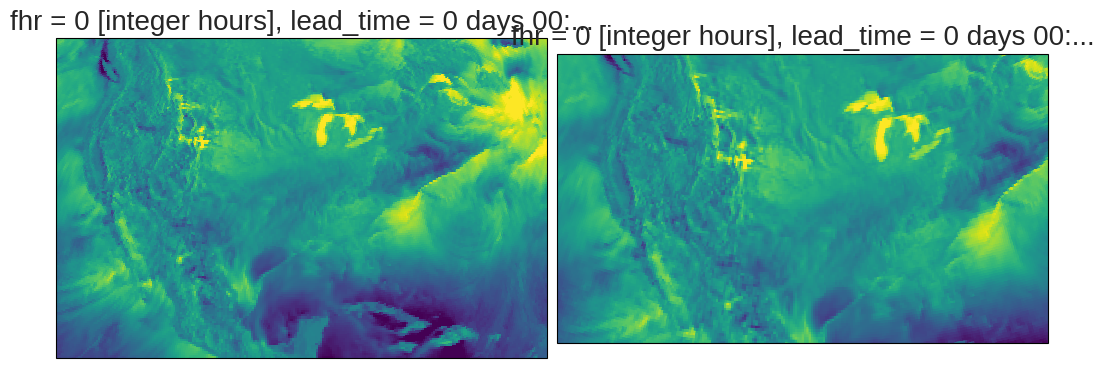

In [63]:
fig, axs = plt.subplots(
    1, 2,
    figsize=(10,8),
    subplot_kw={
        "projection": ccrs.Orthographic(
            central_longitude=-90,
            central_latitude=15,
        )
    }
)
for i, (xds, ax) in enumerate(zip([gfs, gsix], axs)):
    #plotme = xds["t2m"].sel(fhr=0, t0="2023-02-01T06")
    #plotme = plotme - 273.15
    plotme = xds["u10"].sel(fhr=0, t0="2023-02-01T06")
    plotme.plot(
        ax=ax,
        vmin=-10,
        vmax=10,
        transform=ccrs.PlateCarree() if i == 0 else None,
        add_colorbar=False,
    )
    if i == 0:
        ax.set_extent([-120, -60, 15, 55], crs=ccrs.PlateCarree())